<a href="https://colab.research.google.com/github/brardilraj/OTEC-Digital-Twin-AI/blob/main/OTEC_Digital_Twin_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Loading Real NOAA Ocean Data (Bay of Bengal)...
Data successfully loaded! Total Days processed: 4123
Time Range: 2015-01-01 to 2026-04-15

2. Calculating Mathematical Net Power Baseline...
3. Training XGBoost Time-Series Forecaster...
AI Forecasting Accuracy (R²): 99.89%

4. Generating Paper Visualizations...


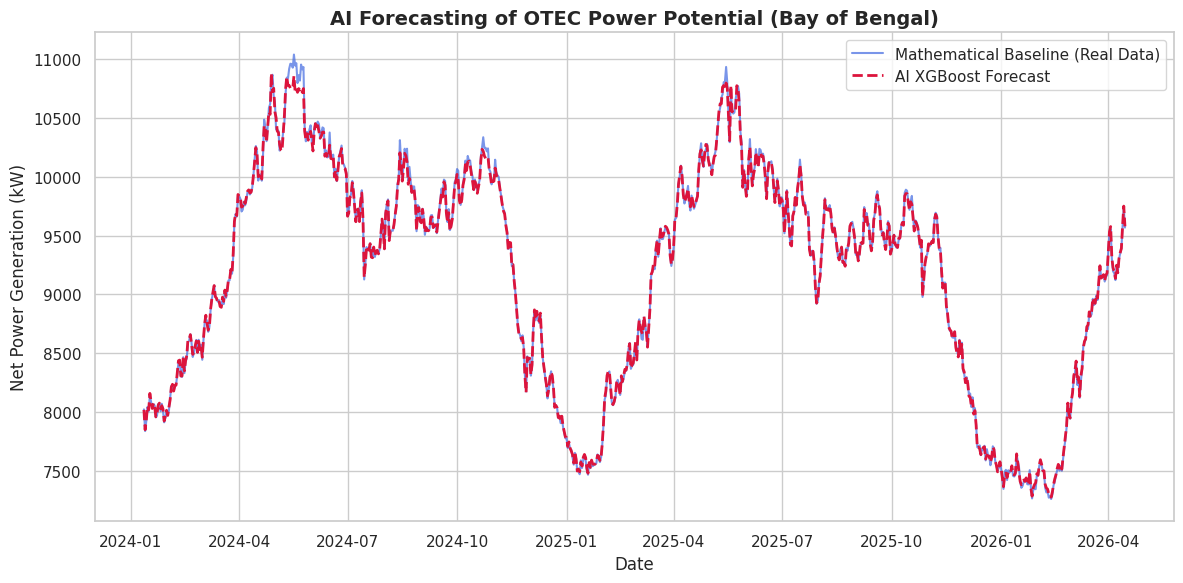

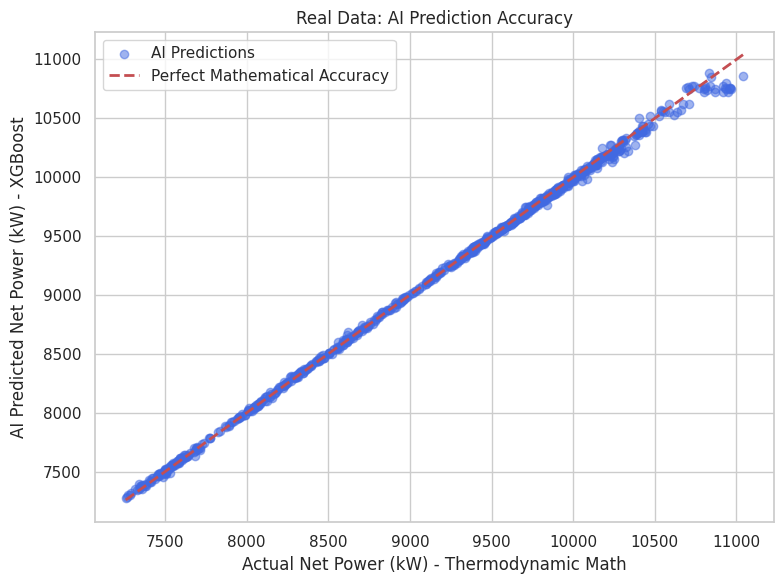

Execution Complete! Download the images from the file menu on the left.


In [2]:
# Install necessary libraries (just in case Colab needs an update)
!pip install -q netCDF4 xarray xgboost

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

# Set professional plotting style for academic papers
sns.set_theme(style="whitegrid")

print("1. Loading Real NOAA Ocean Data (Bay of Bengal)...")
# Make sure the filename matches what you uploaded to Colab!
# If your file is named differently, change 'subset.nc' to your filename.
ds = xr.open_dataset('subset.nc')

# Extract time and Sea Surface Temperature (sst)
# We take the spatial mean across the latitude and longitude grid for each day
sst_series = ds['sst'].mean(dim=['lat', 'lon']).values
dates = ds['time'].values

# Create our real-world dataframe
df = pd.DataFrame({
    'Date': pd.to_datetime(dates),
    'Surface_Temp_C': sst_series
})

# Simulate the highly stable deep ocean temperature at 1000m
# (around 4.5°C with near-zero variance)
np.random.seed(42)
df['Deep_Temp_C'] = 4.5 + 0.1 * np.sin(np.arange(len(dates))*2*np.pi/365) + np.random.normal(0, 0.05, len(dates))

# Drop any missing data points
df = df.dropna()

print(f"Data successfully loaded! Total Days processed: {len(df)}")
print(f"Time Range: {df['Date'].min().date()} to {df['Date'].max().date()}\n")

print("2. Calculating Mathematical Net Power Baseline...")
def calculate_real_net_power(t_surface, t_deep, flow_rate=5000):
    # Convert to Kelvin for Carnot efficiency
    t_warm_k = t_surface + 273.15
    t_cold_k = t_deep + 273.15
    carnot_eff = 1 - (t_cold_k / t_warm_k)
    practical_eff = carnot_eff * 0.30

    # Thermodynamics
    thermal_energy = flow_rate * 3.99 * (t_surface - t_deep)
    gross_power = thermal_energy * practical_eff * 0.85 # 85% turbine eff

    # Parasitic pumping loss (energy required to pump deep water)
    pumping_power = (flow_rate * 9.81 * 15) / (0.75 * 1025)

    return max(0, gross_power - pumping_power)

# Apply the physics formula to every day in the dataset
df['Actual_Net_Power_kW'] = df.apply(lambda row: calculate_real_net_power(row['Surface_Temp_C'], row['Deep_Temp_C']), axis=1)

print("3. Training XGBoost Time-Series Forecaster...")
# Chronological Train/Test Split (80% historical data, 20% future forecasting)
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

X_train = train_df[['Surface_Temp_C', 'Deep_Temp_C']]
y_train = train_df['Actual_Net_Power_kW']

X_test = test_df[['Surface_Temp_C', 'Deep_Temp_C']]
y_test = test_df['Actual_Net_Power_kW']

# Train the AI Model
model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42)
model.fit(X_train, y_train)

# Ask the AI to predict the Net Power for the final 20% of the timeline
predictions = model.predict(X_test)
test_df['Predicted_Power_kW'] = predictions

# Evaluate Model Accuracy
r2 = r2_score(y_test, predictions)
print(f"AI Forecasting Accuracy (R²): {r2 * 100:.2f}%\n")

print("4. Generating Paper Visualizations...")
# --- Figure 1: Time Series Forecast ---
plt.figure(figsize=(12, 6))
plt.plot(test_df['Date'], test_df['Actual_Net_Power_kW'], label='Mathematical Baseline (Real Data)', color='royalblue', alpha=0.7)
plt.plot(test_df['Date'], test_df['Predicted_Power_kW'], label='AI XGBoost Forecast', color='crimson', linestyle='--', linewidth=2)
plt.title('AI Forecasting of OTEC Power Potential (Bay of Bengal)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Net Power Generation (kW)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('real_world_forecast.png', dpi=300)
plt.show()

# --- Figure 2: Scatter Plot Accuracy ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.5, color='royalblue', label='AI Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Mathematical Accuracy')
plt.xlabel("Actual Net Power (kW) - Thermodynamic Math")
plt.ylabel("AI Predicted Net Power (kW) - XGBoost")
plt.title("Real Data: AI Prediction Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig('real_actual_vs_predicted.png', dpi=300)
plt.show()

print("Execution Complete! Download the images from the file menu on the left.")